 Анализа скупа података [10]

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('08_hearth_disease_dataset.csv')
data.columns = data.columns.str.strip()  # jer imam razmake u nazivima
data.replace(['?', 'NA', 'NaN', 'nan', ''], np.nan, inplace=True)

# pretvaram object u float da mogu da racunam mean, mediana:
data.fbs = data.fbs.astype(float)
data.restecg = data.restecg.astype(float)
data.exang = data.exang.astype(float)
data.oldpeak = data.oldpeak.astype(float)
data.slope = data.slope.astype(float)
data.ca = data.ca.astype(float)
data.thal = data.thal.astype(float)
# nema smisla da budu 0:
data.trestbps = data.trestbps.replace('0', np.nan).astype(float)
data.chol = data.chol.replace('0', np.nan).astype(float)
data.thalach = data.thalach.replace('0', np.nan).astype(float)

data.info()
data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    int64  
 3   trestbps  860 non-null    float64
 4   chol      718 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 100.8 KB


,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.00,77.0
sex,920.0,0.789130,0.408148,0.0,1.0,1.0,1.00,1.0
cp,920.0,3.250000,0.930969,1.0,3.0,4.0,4.00,4.0
trestbps,860.0,132.286047,18.536175,80.0,120.0,130.0,140.00,200.0
chol,718.0,246.832869,58.527062,85.0,210.0,239.5,276.75,603.0
fbs,830.0,0.166265,0.372543,0.0,0.0,0.0,0.00,1.0
restecg,918.0,0.604575,0.805827,0.0,0.0,0.0,1.00,2.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.00,202.0
exang,865.0,0.389595,0.487941,0.0,0.0,0.0,1.00,1.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.50,6.2


Од неадекватних вредности, 0 код trestbps, chol и thalach смо заменили са NaN, као и ? из свих колона у којима се појављују. Такође, квантитативне променљиве типа object смо конвертовали у float како бисмо са њима могли даље да радимо.

Из добијених таблица видимо да нам колоне ca и thal имају преко 50% NaN вредности па ћемо их у потпуности уклонити. У осталим колонама, непознате вредности мењамо са најчешћом (за дискретне случајне променљиве) или медијаном јер нам све колоне имају outliere (за континуалне случајне променљиве).


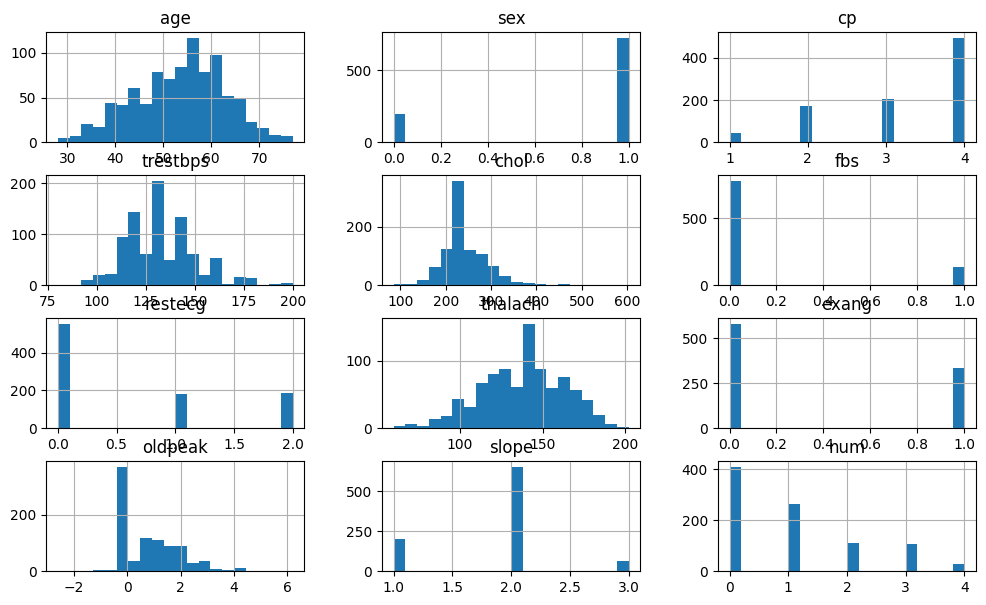

In [ ]:
data = data.drop(columns = 'ca')
data = data.drop(columns = 'thal')
data.trestbps = data.trestbps.fillna(data.trestbps.median())
data.chol = data.chol.fillna(data.chol.median())
data.thalach = data.thalach.fillna(data.thalach.median())
data.oldpeak = data.oldpeak.fillna(data.oldpeak.median())
data.fbs = data.fbs.fillna(data.fbs.mode()[0])
data.restecg = data.restecg.fillna(data.restecg.mode()[0])
data.exang = data.exang.fillna(data.exang.mode()[0])
data.slope = data.slope.fillna(data.slope.mode()[0])

data.hist(bins=20, figsize=(12,7))
plt.show()

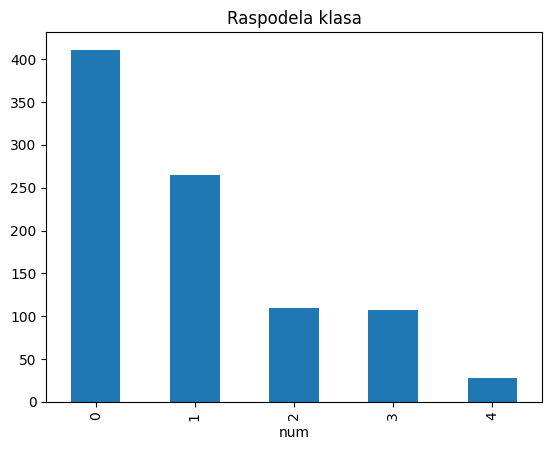

In [ ]:
klasa = data.num

p0 = sum(klasa == 0)/np.size(klasa) # 0.4467391304347826
p1 = sum(klasa == 1)/np.size(klasa) # 0.28804347826086957
p2 = sum(klasa == 2)/np.size(klasa) # 0.11847826086956521
p3 = sum(klasa == 3)/np.size(klasa) # 0.11630434782608695
p4 = sum(klasa == 4)/np.size(klasa) # 0.030434782608695653

klasa.value_counts().plot.bar(title='Raspodela klasa')
plt.show()

 Селекција обележја [13]

In [ ]:
def calculateInfoD(col):
    un = np.unique(col)
    infoD = 0
    for u in un:
        p = sum(col == u)/len(col)
        infoD -= p*np.log2(p)
    return infoD

infoD = calculateInfoD(klasa)
IG = []
brojKoraka = 10
for ob in range(data.shape[1] - 1):
    kol = data.iloc[:, ob]
    f = np.unique(kol)

    if len(f) > brojKoraka:
        korak = (max(kol) - min(kol)) / brojKoraka
        kol = np.floor(kol / korak) * korak
        f = np.unique(kol)

    infoDA = 0
    for i in f:
        temp = klasa[kol == i]
        infoDi = calculateInfoD(temp)
        Di = sum(kol == i)
        D = len(kol)
        infoDA += Di * infoDi / D

    IG.append([data.columns[ob], infoD - infoDA])

IGdf = pd.DataFrame(IG, columns=['obelezje', 'IG'])
IGsorted = IGdf.sort_values(by=['IG'], ascending=False, ignore_index=True)
print(IGsorted)

    obelezje        IG
0         cp  0.233486
1    oldpeak  0.163578
2    thalach  0.148545
3      exang  0.146432
4        age  0.113623
5        sex  0.070653
6   trestbps  0.044644
7      slope  0.042199
8       chol  0.033108
9    restecg  0.029446
10       fbs  0.013433


Тренутно имамо 11 обележја. Видимо да је најмање информативно обележје fbs па њега избацујемо.

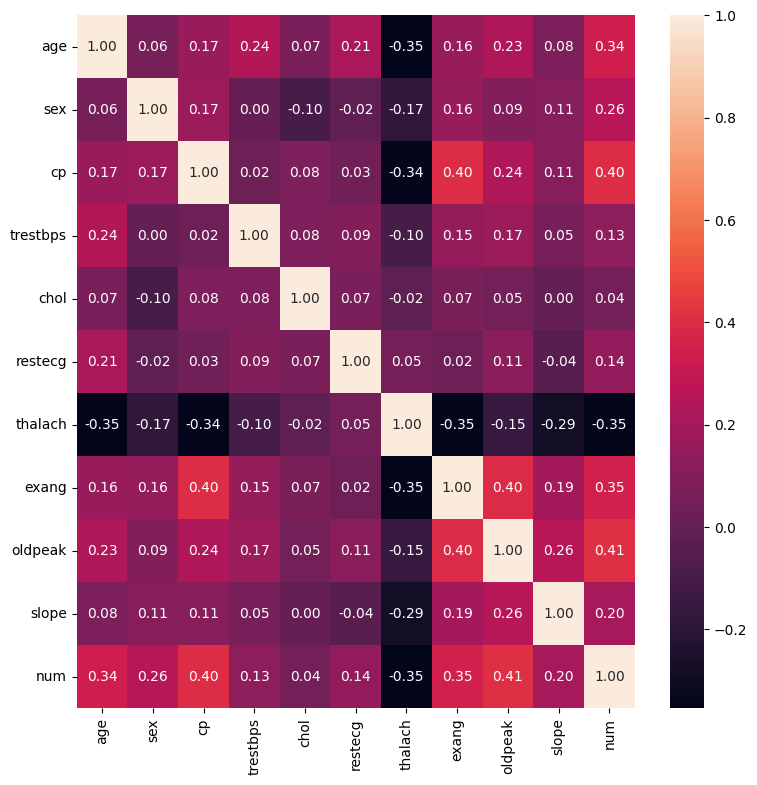

In [ ]:
import seaborn as sns

data = data.drop(columns='fbs')      # najmanje informativna
#data = data.drop(columns='restecg')
#data = data.drop(columns='chol')

# Pirsonovim koef korelacije
pearson_R = data.corr(method='pearson')
plt.figure(figsize=(9, 9))
sns.heatmap(pearson_R, annot=True, fmt=".2f")
plt.yticks(rotation=0)
plt.show()

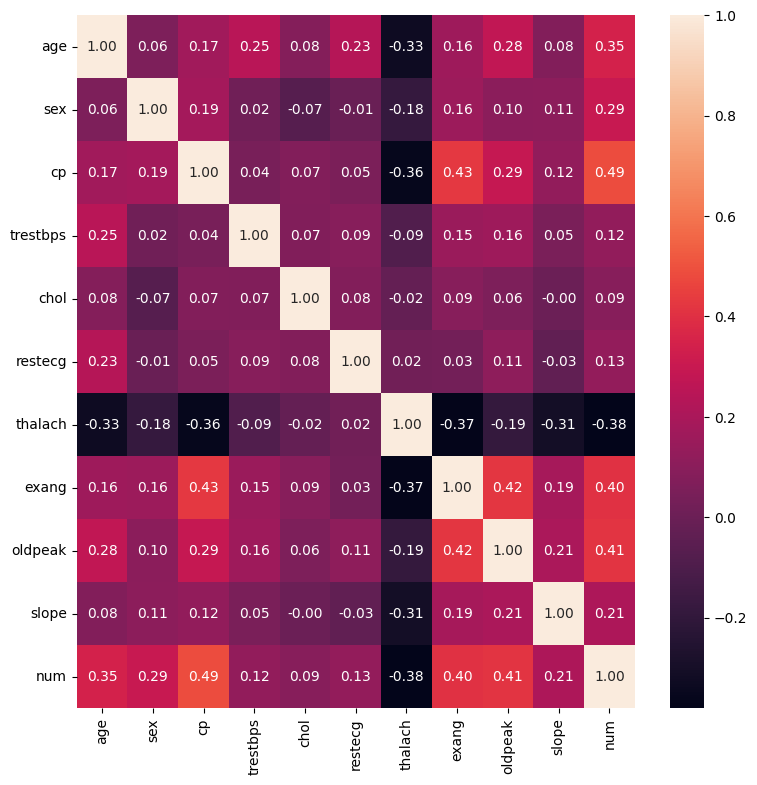

In [ ]:
# Spirmanovim koef korelacije
spearman_R = data.corr(method='spearman')
plt.figure(figsize=(9, 9))
sns.heatmap(spearman_R, annot=True, fmt=".2f")
plt.yticks(rotation=0)
plt.show()

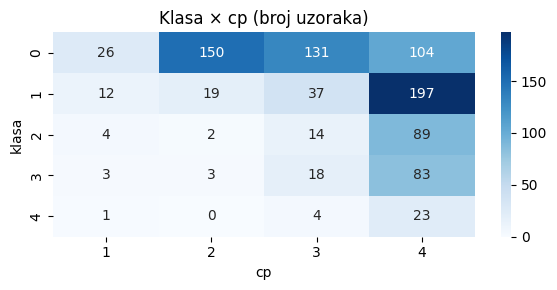

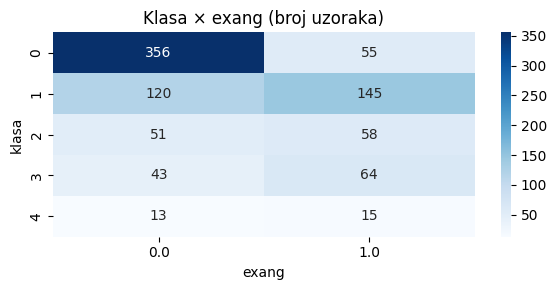

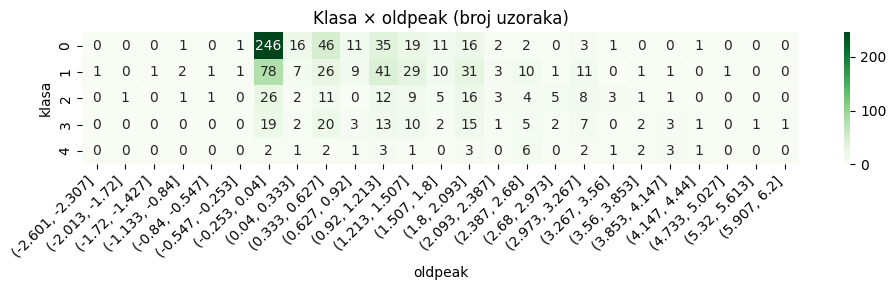

In [ ]:
# raspodela za cp i exang
import seaborn as sns
tab_cp = pd.crosstab(data['num'], data['cp'])  # index=klasa, columns=cp
plt.figure(figsize=(6,3))
sns.heatmap(tab_cp, annot=True, fmt='d', cmap='Blues')
plt.xlabel('cp'); plt.ylabel('klasa'); plt.title('Klasa × cp (broj uzoraka)')
plt.tight_layout(); plt.show()

tab_cp = pd.crosstab(data['num'], data['exang'])  # index=klasa, columns=cp
plt.figure(figsize=(6,3))
sns.heatmap(tab_cp, annot=True, fmt='d', cmap='Blues')
plt.xlabel('exang'); plt.ylabel('klasa'); plt.title('Klasa × exang (broj uzoraka)')
plt.tight_layout(); plt.show()



n_bins = 30
bins = np.linspace(data['oldpeak'].min(), data['oldpeak'].max(), n_bins+1)
oldpeak_binned = pd.cut(data['oldpeak'], bins=bins, include_lowest=True)
tab_oldpeak = pd.crosstab(data['num'], oldpeak_binned)
plt.figure(figsize=(10,3))
sns.heatmap(tab_oldpeak, annot=True, fmt='d', cmap='Greens')
plt.xlabel('oldpeak'); plt.ylabel('klasa'); plt.title('Klasa × oldpeak (broj uzoraka)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

По оба метода високу корелацију са класом показују обележја cp и exang.

Због небалансираности класа (највише 0), резултати нису идеални. Ипак, видимо да је међу пацијентима са неким степеном коронарне болести највише присутан бол у грудима типа 3 и 4.
Такође, видимо да је обележје exang једнако 0 тј. ангина узрокована вежбом није присутна, чешће код здравих пацијената, а присутна је код више пацијената са обољењем.


 Редукција димензија [12]


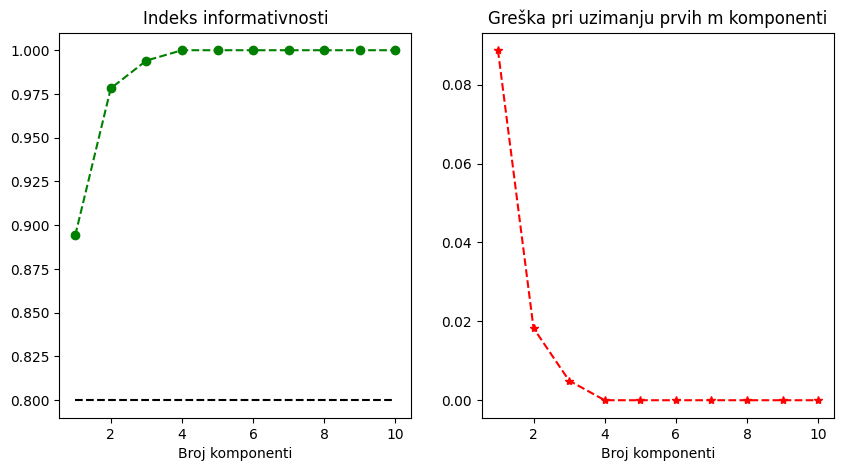

In [ ]:
#LDA

X = data.drop(columns='num')
y = data.num
# normalizacija metodom standardizacije
m = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_norm = (X - m) / std

def parametri(X, y, klasa):
    Xk = X.loc[y==klasa, :]
    p = Xk.shape[0]/X.shape[0]
    M = Xk.mean().values.reshape(Xk.shape[1],1)
    S = Xk.cov()

    return (p, M, S)

# parametri po klasi
params = []
for i in sorted(y.unique()):
    params.append(parametri(X_norm, y, i))

Mc = sum(p*M for (p,M,S) in params)
Sw = sum(p*S for (p,M,S) in params)
Sb = sum(p*(M-Mc)@(M-Mc).T for (p,M,S) in params)

S = np.linalg.inv(Sw)@Sb
eigval, eigvec = np.linalg.eig(S)
idx = np.argsort(eigval)[::-1]
eigval = eigval[idx]; eigvec = eigvec[:, idx]

lda_var = eigval / np.sum(eigval)
lda_info_idx = np.cumsum(lda_var)

lda_err = np.zeros(eigval.shape)
for k in range(eigval.size):
    lda_err[k] = np.sum(eigval[k+1:])

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(np.arange(len(lda_var))+1, lda_info_idx, 'go--')
plt.plot([1, 10], [0.8, 0.8], 'k--')
plt.title('Indeks informativnosti')
plt.xlabel('Broj komponenti')


plt.subplot(122)
plt.plot(np.arange(len(lda_err))+1, lda_err, 'r*--')
plt.title('Greška pri uzimanju prvih m komponenti')
plt.xlabel('Broj komponenti')
plt.show()

Према индексу информативности, сваки одабир је адекватан, а с обзиром да имамо 5 класа, максималан број компоненти које можемо узети је 4. Ми ћемо упоредити резултате за 2 и 3 компоненте.

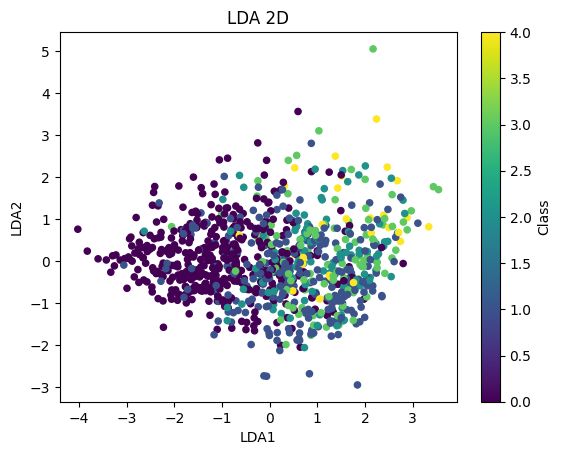

In [ ]:
no_comp = 2
A = eigvec[:, :no_comp]

Y = A.T @ X_norm.T
Y = Y.T

LDAdf = pd.concat([Y , y] , axis = 1)
LDAdf.columns = ['LDA1', 'LDA2', 'Class']

LDAdf.plot(x='LDA1', y='LDA2', kind='scatter', c='Class', colormap='viridis', title = 'LDA 2D')
plt.show()

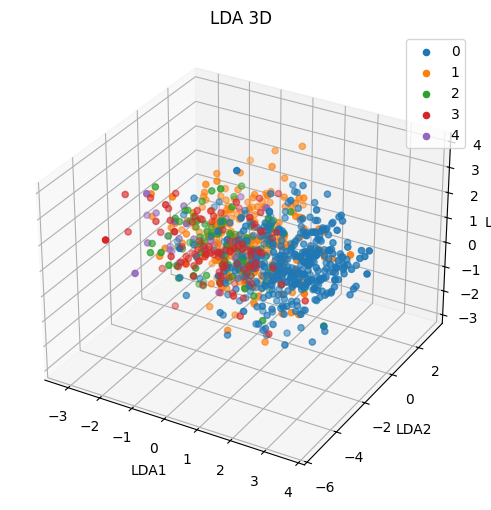

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from mpl_toolkits.mplot3d import Axes3D # za 3D plotting

no_comp2 = 3
lda = LDA(solver='eigen', n_components=no_comp2)
ldaComponents = lda.fit_transform(X_norm, y)

ldaComponents = pd.DataFrame(data = ldaComponents)

LDAdf3 = pd.concat([ldaComponents, y] , axis = 1)
LDAdf3.columns = ['LDA1', 'LDA2', 'LDA3', 'Class']
LDAdf3.head()

# 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for name, group in LDAdf3.groupby('Class'):
    ax.scatter(group['LDA1'], group['LDA2'], group['LDA3'], label=name)

ax.set_xlabel('LDA1')
ax.set_ylabel('LDA2')
ax.set_zlabel('LDA3')
ax.set_title('LDA 3D')
ax.legend()

plt.show()

Видимо да ни у једном ни у другом случају наш проблем није сепарабилан. Ипак, примећујемо да је класа 0, коју чине здрави пацијенти, релативно добро одвојена од осталих. Због тога, и небалансираности класа, ћемо надаље спојити све степене болести у једну класу, класу болесних (1), и радити са две класе. На тај начин ћемо добити модел који предвиђа присуство коронарне болести, али не и њен степен озбиљности. За модел који би могао да разликује степене болести било би потребно више података и додатна обележја која би их боље раздвојила.

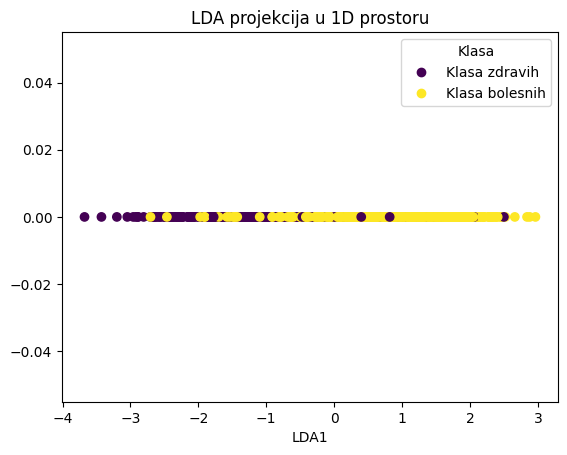

In [ ]:
data['num']=data['num'].replace({2:1,3:1,4:1})
X = data.drop(columns='num')
Y = data.num
# normalizacija metodom standardizacije
m = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_norm = (X - m) / std

no_comp = 1
lda = LDA(solver='eigen', n_components=no_comp)
ldaComponents = lda.fit_transform(X_norm,Y)
ldaComponents = pd.DataFrame(data = ldaComponents)

LDAdf1 = pd.concat([ldaComponents, Y] , axis = 1)
LDAdf1.columns = ['LDA1', 'Class']
LDAdf1.head()

sc = plt.scatter(LDAdf1['LDA1'], np.zeros(len(LDAdf1)), c=LDAdf1['Class'])
handles, _ = sc.legend_elements()
plt.legend(handles, ['Klasa zdravih', 'Klasa bolesnih'], title='Klasa')

plt.xlabel('LDA1')
plt.title('LDA projekcija u 1D prostoru')
plt.show()



Иако класе и даље нису потпуно сепарабилне, резултати су значајно бољи, тако да ћемо покушати да овакав скуп поделимо неком од параметарских метода класификације.

 Тестирање хипотеза и параметарска класификација [15]


С обзиром да радимо са реалним одбирцима, не знамо њихову расподелу. Стога, класификатор пројектујемо тако што цео улазни скуп поделимо на тренинг и тест, и онда тренинг сет користимо за процену параметара (М и сигма), а тест скуп за проверу успешности класификатора. При том претпостављамо нормалну расподелу података.

У нашем задатку имамо 2 класе, здравих и болесних, а пошто је у медицини много важније да некога ко је болестан не прогласимо здравим него обрнуто, користићемо Бајесов класификатор минималне цене. За цену с12 ћемо ставити 10 пута већу вредност како бисмо то постигли.

Prag će se nalaziti na -0.39


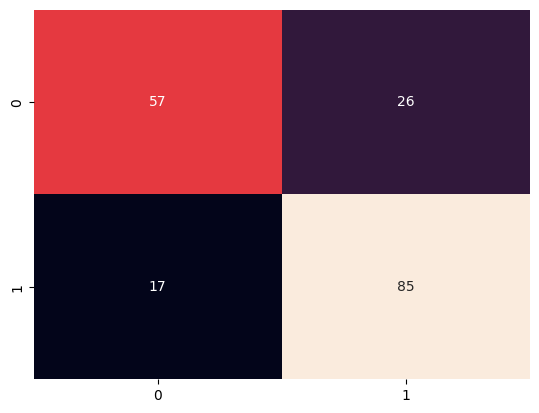

Tacnost klasifikacije iznosti 76.76%
Preciznost klasifikacije iznosti 76.58%
Senzitivnost klasifikacije iznosti 83.33%
Specificnost klasifikacije iznosti 68.67%
Stopa lažno negativnih iznosti 16.67%


In [ ]:
from sklearn.model_selection import train_test_split
XLDA = LDAdf1.drop(columns='Class')
YLDA = LDAdf1['Class']

X0 = XLDA.loc[Y == 0, :]
N0 = X0.shape[0]
Y0 = YLDA[Y==0]

X1 = XLDA.loc[Y == 1, :]
N1 = X1.shape[0]
Y1 = YLDA[Y==1]

multiline_comment = """
def trening_test_podela(X, per, klasa):
    N = X.shape[0]
    Ntrening = int(per * N)
    Ntest = N - Ntrening

    Xtrening = X[:Ntrening].reset_index(drop=True)
    Ytrening = klasa * np.ones((Ntrening, 1))

    Xtest = X[Ntrening:].reset_index(drop=True)
    Ytest = klasa * np.ones((Ntest, 1))

    return Xtrening, Ytrening, Xtest, Ytest
#X0trening, Y0trening, X0test, Y0test = trening_test_podela(X0, 0.8, 0)
#X1trening, Y1trening, X1test, Y1test = trening_test_podela(X1, 0.8, 1)"""

X0trening, X0test, Y0trening, Y0test = train_test_split(X0, Y0, train_size=4/5, random_state=42, shuffle=True)
X1trening, X1test, Y1trening, Y1test = train_test_split(X1, Y1, train_size=4/5, random_state=42, shuffle=True)

M0p = X0trening.mean()
S0p = X0trening.cov()
M1p = X1trening.mean()
S1p = X1trening.cov()

def izracunaj_fgv(x, m, s):
    det = np.linalg.det(s)
    inv = np.linalg.inv(s)
    x_mu = x - m

    fgv_const = 1/np.sqrt(2*np.pi*det)
    fgv_rest = np.exp(-0.5*x_mu.T@inv@x_mu)
    return fgv_const*fgv_rest

p0 = X0trening.shape[0] / X0.shape[0]
p1 = X1trening.shape[0] / X1.shape[0]
c11 = 0
c22 = 0
c12 = 10
c21 = 1
T = - np.log(p2/p1*(c22-c12)/(c11-c21))
print(f'Prag će se nalaziti na {T:.2f}')

def donosenje_odluke(x, m1, m2, s1, s2):
    f1 = izracunaj_fgv(x, m1, s1)
    f2 = izracunaj_fgv(x, m2, s2)
    h = -np.log(f1) + np.log(f2)
    if h < T:
        odluka = 0
    else:
        odluka = 1

    return odluka

odluka = np.zeros((X0test.shape[0] + X1test.shape[0], 1))

for i in range(X0test.shape[0]):
    x0 = X0test.iloc[i, :]
    odluka[i] = donosenje_odluke(x0, M0p, M1p, S0p, S1p)

for i in range(X1test.shape[0]):
    x1 = X1test.iloc[i, :]
    odluka[i+X0test.shape[0]] = donosenje_odluke(x1, M0p, M1p, S0p, S1p)

Xtest = np.append(X0test, X1test, axis=0)
Ytest = np.append(Y0test, Y1test, axis=0)

from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(Ytest, odluka)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

 Непараметарска класификација [20] - KNN




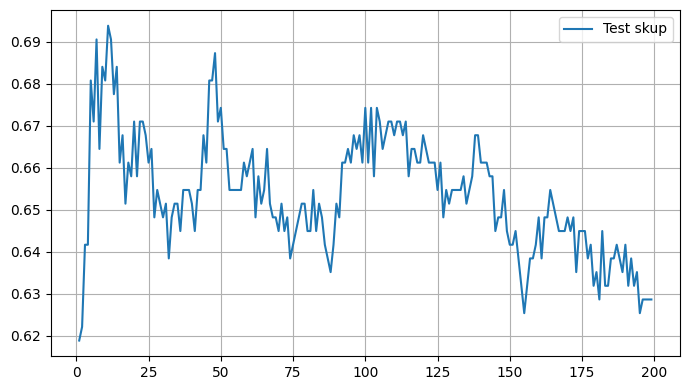

Najbolja tacnost se dobija za K=11 i iznosi 69.38%.


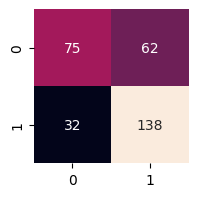

Tacnost klasifikacije iznosti 69.38%
Preciznost klasifikacije iznosti 69.00%
Senzitivnost klasifikacije iznosti 81.18%
Specificnost klasifikacije iznosti 54.74%
Stopa lažno negativnih iznosti 18.82%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier as KNN

X = data.drop(columns = 'num')
Y = data.num
Xtrening, Xtest, Ytrening, Ytest = train_test_split(X, Y, train_size=2/3, random_state=42, stratify=Y, shuffle=True)

k = np.arange(1, 200)
acc_test = np.zeros((k.size,))
for i in range(k.size):
    knn_model = KNN(n_neighbors=k[i])
    knn_model.fit(Xtrening, Ytrening)
    acc_test[i] = accuracy_score(Ytest, knn_model.predict(Xtest))

plt.figure(figsize=(7,4))
plt.plot(k, acc_test, label='Test skup')
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()

bestAcc = np.max(acc_test)
bestK = k[np.argmax(acc_test)]
print(f'Najbolja tacnost se dobija za K={bestK} i iznosi {100*bestAcc:.2f}%.')

k = bestK

pred = np.zeros((Xtest.shape[0],))
for i in range(Xtest.shape[0]):
    tren_test = Xtest.iloc[i, :]
    dist = np.zeros((Xtrening.shape[0],))
    for j in range(Xtrening.shape[0]):
        tren_trening = Xtrening.iloc[j, :]

        dist[j] = np.sqrt(np.sum((tren_test - tren_trening)**2))

    idx = np.argsort(dist)[:k]
    najblizi_klase = Ytrening.iloc[idx]

    val, cnt = np.unique(najblizi_klase, return_counts=True)

    pred[i] = val[np.argmax(cnt)]

acc = accuracy_score(Ytest, pred)

conf_mat = confusion_matrix(Ytest, pred)
plt.figure(figsize=(2,2))
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

 Неуралне мреже [20]

In [ ]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

from keras import Sequential
from keras.layers import Input, Dense

X = data.drop(columns = 'num')
Y = data['num']

Xtrening, Xtest, Ytrening, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=20, stratify = Y)
Xtrening, Xval, Ytrening, Yval = train_test_split(Xtrening, Ytrening, test_size=0.2, shuffle=True, random_state=20, stratify = Ytrening)

model = Sequential()
model.add(Input(shape=(Xtrening.shape[1], )))
model.add(Dense(300, activation='relu'))
model.add(Dense(200, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(200, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(100, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation='sigmoid')) # za 2 klase 1 izlaz
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,901 (483.99 KB)

 Trainable params: 123,901 (483.99 KB)

 Non-trainable params: 0 (0.00 B)

Улазни слој има онолико неурона колико имамо обележја, у нашем случају 10, а излазни 1 јер имамо 2 класе. Провером вредности критеријумске функције на тест и валидационом скупу одредићемо адекватан број слојева и неурона који даје задовољавајуће резултате, а не доводи до преобучавања.

In [ ]:
max_epochs = 200
es = EarlyStopping(monitor='val_loss', mode='min', patience=20, verbose=1)

model.compile('adam', loss = 'binary_crossentropy', metrics=['accuracy'])
#history = model.fit(x=Xtrening, y=Ytrening, epochs=max_epochs, batch_size=64, shuffle=True, validation_data=(Xval, Yval), callbacks=[es], verbose = 1)
history = model.fit(x=Xtrening, y=Ytrening, epochs=max_epochs, batch_size=64, shuffle=True, validation_data=(Xval, Yval), verbose=1)

Ypred = model.predict(Xtest, verbose=0)
Ypred = np.round(Ypred) # jer sigmoid vraca vr blizu 0 i 1, ne tacne, zaokruzujemo na 0 i 1

conf_mat = confusion_matrix(Ytest, Ypred)
plt.figure(figsize=(2,2))
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4805 - loss: 12.1101 - val_accuracy: 0.4459 - val_loss: 6.9266
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4818 - loss: 6.2361 - val_accuracy: 0.6689 - val_loss: 4.8077
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6010 - loss: 4.8306 - val_accuracy: 0.6284 - val_loss: 4.3619
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6252 - loss: 4.2784 - val_accuracy: 0.5743 - val_loss: 4.0951
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6081 - loss: 3.8884 - val_accuracy: 0.6216 - val_loss: 3.5545
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6469 - loss: 3.4382 - val_accuracy: 0.6554 - val_loss: 3.2485
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6812 - loss: 3.1547 - val_accuracy: 0.6892 - val_loss: 3.0260
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6560 - loss: 2.9906 - val_accuracy: 0

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Trening skup')
plt.plot(history.history['val_loss'], label='Validacioni skup')
plt.title("Vrednost kriterijumske funkcije (greška)")
plt.legend()
#plt.xlim(0, 100)
plt.xlabel("Epohe")
plt.grid()
plt.show()

Добар одабир

С обзиром да немамо велики број података, мрежа је склона преобучавању. Због тога смо користили само 1 скривени слој од 10 неурона. Тиме смо постигли тачност на тест скупу од око 80% уз 10% пропуштених детекција (лажно негативних) и грешку на валидационом скупу од око 0.5. Такође, видимо да грешка и на тренинг и на валидационом скупу почиње да стагнира већ на око 60 епоха тј брзо опадне, али не на 0.

Премало неурона

За пример са премалим бројем неурона узели смо најједноставнију мрежу, само са улазним и излазним слојем. Видимо да је тачност класификатора значајно лошија, са 27% лажно негативних. Грешке на тренинг и валидационом скупу спорије опадају тако да је потребан већи број епоха како би се стационирале. После 200 епоха, грешка на валидационом скупу нам је пала на 3.56 што је 7 пута веће од претходно добијене. Закључујемо да је неурална мрежа са оваквом структуром недовољно обучена.

Преобучавање

За преобучавање смо направили неуралну мрежу са 4 скривена слоја од по 300, 200, 200 и 100 неурона. Као што је и очекивано, тачност на тест скупу је опала, а грешка на валидационом није више монотона опадајућа. Сада ћемо увести рано заустављање које прекида епохе након што грешка на валидационом довољно порасте.

Рано заустављање

Рано заустављање је техника спречавања преобучавања која подразумева да се обучавање неуралне мреже заустави када грешка на подацима које неуралне мрежа није видела крене да расте.

Ова метода подразумева да се скуп података подели на скуп података за тренинг и скуп података за валидацију неуралне мреже. Током тренирања, мрежи се прослеђују оба скупа, и паралелно се гледа грешка класификације на њима. Током тренирања грешка на тренинг скупу ће константно да опада, док ће грешка на валидационом скупу у једном тренутку кренути да расте. Тај тренутак представља тренутак раног заустављања.

Зауставили смо се на 104 епохе, од 200.

Регуларизација

Регуларизација служи да спречи преобучавање неуралне мреже додавањем члана у критеријумску функцију који пенализује велике вредности тежина. Када модел има велике тежине, онда мале промене улазних параметара доводе до великих промена на излазу. Постоје L1 и L2 техника регуларизаиције:
L1 :L(ω)=E(ω)+λ⋅∑∣ω∣
L2: L(ω)=E(ω)+λ⋅∑ω^2
У зависности од параметра λ регуларизација има мањи или већи утицај.

Предност L1 технике регуларизације је у томе што је отпорна на outliere, док је предност L2 технике регуларизације то што може да научи комплексније облике података. Ми ћемо користити L2 регуларизацију у скривеним слојевима од 200, 200 и 100 неурона. Видимо да је разлика између грешке на тренинг и валидационом скупу сада мања, са минималном вредношћу око 0.7. Такође, тачност је повећана у односу на тачност преобучене мреже.


 Компаративна анализа [10]


In [ ]:
tabela = [
    ["76,58%          ", "69,00%", "77,12%    "],
    ["83,33%          ", "81,18%", "89,22%    "],
    ["68,67%          ", "54,74%", "67,07%    "],
    ["76,76%          ", "69,38%", "79,35%    "]
]
kol = ["Bajesov klasifikator min cene", "KNN ", "    Neuralne mreže"]
red = ["Preciznost","Senzitivnost", "Specifičnost", "Tačnost"]
df = pd.DataFrame(tabela, columns = kol, index = red)
print(df)

У медицини најбитније висока сензитивност тако да су неуралне мреже дале најбољи резултат.